# 03. Multivariate Dependence, DCC-GARCH and Forbes-Rigobon Adjustment

The univariate GARCH notebook told us whether each market became more volatile after COVID-19. This notebook now moves to the second dimension of the project: **co-movement**. If the structure of risk changed, it should not only appear in each asset separately, but also in the way markets move together.

We therefore study:
- rolling 52-week correlations across key pairs;
- a bivariate DCC-GARCH model for the central SPX / US 10Y relation;
- the Forbes-Rigobon adjustment to correct raw correlation comparisons when volatility changes sharply across samples.

## 1. Setup

We reuse the same cleaned daily series built in notebook 01. This guarantees that any change in co-movement comes from the data rather than from a different alignment rule or transformation choice.

In [1]:
from _notebook_setup import bootstrap_notebook

bootstrap_notebook()

import pandas as pd
import matplotlib.pyplot as plt

from project2_multivariate_utils import (
    KEY_PAIRS,
    DCC_PAIRS,
    PAIR_LABELS,
    ROLLING_WINDOW,
    load_multivariate_samples,
    rolling_correlation_table,
    plot_rolling_correlations,
    summarize_rolling_correlations,
    fit_bivariate_dcc,
    plot_dcc_path,
    summarize_dcc_path,
    build_forbes_rigobon_table,
    save_multivariate_outputs,
)
from project2_data_utils import ensure_output_dirs, save_figure, save_dataframe

ensure_output_dirs()

## 2. Load the aligned daily sample

The analysis again relies on the exact pre/post split used in the first two notebooks. This matters because rolling correlations and DCC estimates are very sensitive to missing observations and date alignment.

In [2]:
aligned_returns, pre_covid, post_covid = load_multivariate_samples()

print(f"Full aligned sample: {aligned_returns.shape}")
print(f"Pre-COVID sample:    {pre_covid.shape}")
print(f"Post-COVID sample:   {post_covid.shape}")

Full aligned sample: (5486, 15)
Pre-COVID sample:    (4181, 15)
Post-COVID sample:   (1305, 15)


## 3. Rolling 52-week correlations

A rolling correlation is the simplest way to visualize whether dependence is stable or regime-dependent. We use a **252-trading-day window**, which is the natural daily approximation to one year. This lets us see whether the COVID period marks a durable shift in the sign, level or instability of key cross-asset links.

We focus on four pairs that are economically central:
- S&P 500 vs US 10Y yield change,
- S&P 500 vs US HY Bonds,
- S&P 500 vs Oil futures,
- Gold vs US 10Y yield change.

In [3]:
rolling_table = rolling_correlation_table(aligned_returns, KEY_PAIRS, window=ROLLING_WINDOW)
rolling_summary = summarize_rolling_correlations(rolling_table)
rolling_summary

,pair,pre_mean_rolling_corr,post_mean_rolling_corr,change_post_minus_pre,pre_std_rolling_corr,post_std_rolling_corr,pre_min_rolling_corr,post_min_rolling_corr,pre_max_rolling_corr,post_max_rolling_corr
0,S&P 500 vs US 10Y yield change,0.3450,0.0916,-0.2534,0.1996,0.2756,-0.1205,-0.2274,0.7128,0.6437
1,S&P 500 vs US HY Bonds,0.3018,0.5730,0.2712,0.1490,0.0689,-0.0661,0.3847,0.6132,0.8224
2,S&P 500 vs Oil futures,0.2078,0.1409,-0.0669,0.2220,0.1040,-0.2019,-0.0713,0.6321,0.5222
3,Gold vs US 10Y yield change,-0.2053,-0.3346,-0.1293,0.1772,0.1292,-0.6728,-0.5884,0.1715,-0.0454


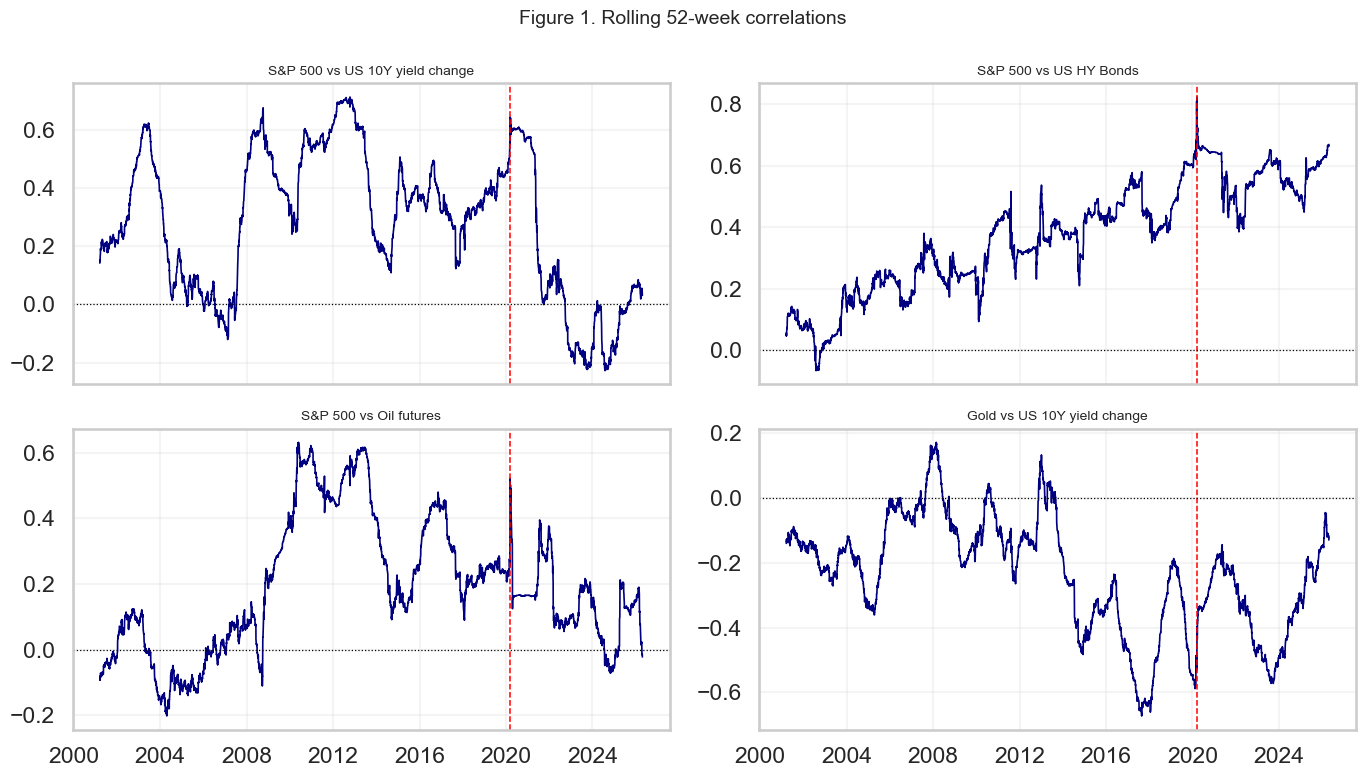

In [4]:
rolling_figure = plot_rolling_correlations(rolling_table)
save_figure(rolling_figure, "03_rolling_correlations.png")
plt.show()

## 4. DCC focus: sovereign rates first, credit second

Among all pairs, the SPX / US 10Y relation is the most informative for the project because it captures the changing interaction between risky assets and the benchmark sovereign yield curve. In calm times, this link often reflects growth expectations. In stress periods, it may flip sign or become unstable as markets move into a flight-to-quality regime.

That said, the post-COVID risk structure is not only about rates. Credit risk is another natural transmission channel, so we also estimate a second **bivariate DCC-GARCH** model for **SPX / US HY Bonds**. This gives us one rates-based pair and one credit-sensitive pair.

In [5]:
spx_ust_pair = aligned_returns[["date", "sp500", "ust10y_yield"]].dropna().copy()
spx_hy_pair = aligned_returns[["date", "sp500", "us_hy_bonds"]].dropna().copy()

spx_ust_result = fit_bivariate_dcc(spx_ust_pair, pair_name=PAIR_LABELS[DCC_PAIRS[0]])
spx_hy_result = fit_bivariate_dcc(spx_hy_pair, pair_name=PAIR_LABELS[DCC_PAIRS[1]])

dcc_parameter_summary = pd.DataFrame([
    {
        "pair": spx_ust_result["pair"],
        "dcc_alpha": spx_ust_result["alpha"],
        "dcc_alpha_se": spx_ust_result["alpha_se"],
        "dcc_alpha_tstat": spx_ust_result["alpha_tstat"],
        "dcc_beta": spx_ust_result["beta"],
        "dcc_beta_se": spx_ust_result["beta_se"],
        "dcc_beta_tstat": spx_ust_result["beta_tstat"],
        "dcc_persistence": spx_ust_result["persistence"],
        "optimization_success": spx_ust_result["success"],
    },
    {
        "pair": spx_hy_result["pair"],
        "dcc_alpha": spx_hy_result["alpha"],
        "dcc_alpha_se": spx_hy_result["alpha_se"],
        "dcc_alpha_tstat": spx_hy_result["alpha_tstat"],
        "dcc_beta": spx_hy_result["beta"],
        "dcc_beta_se": spx_hy_result["beta_se"],
        "dcc_beta_tstat": spx_hy_result["beta_tstat"],
        "dcc_persistence": spx_hy_result["persistence"],
        "optimization_success": spx_hy_result["success"],
    },
])

dcc_path_summary = pd.concat([
    summarize_dcc_path(spx_ust_result["dcc_path"]).assign(pair=spx_ust_result["pair"]),
    summarize_dcc_path(spx_hy_result["dcc_path"]).assign(pair=spx_hy_result["pair"]),
], ignore_index=True)

dcc_parameter_summary

,pair,dcc_alpha,dcc_alpha_se,dcc_alpha_tstat,dcc_beta,dcc_beta_se,dcc_beta_tstat,dcc_persistence,optimization_success
0,S&P 500 vs US 10Y yield change,0.0555,0.0066,8.3601,0.9238,0.0102,90.1820,0.9793,True
1,S&P 500 vs US HY Bonds,0.0095,0.0041,2.3066,0.9872,0.0077,127.4734,0.9968,True


## 5. Dynamic conditional correlation paths

The DCC path gives a filtered measure of time-varying dependence after controlling for univariate volatility clustering in each series. Economically, this matters because a raw correlation can move simply because each market becomes more volatile, not necessarily because the transmission mechanism itself changes. We therefore summarize the average DCC correlation before and after COVID for both pairs, then inspect the two paths directly.

In [6]:
dcc_path_summary

,pre_mean_dcc_corr,post_mean_dcc_corr,change_post_minus_pre,pre_std_dcc_corr,post_std_dcc_corr,pre_min_dcc_corr,post_min_dcc_corr,pre_max_dcc_corr,post_max_dcc_corr,pair
0,0.3068,0.0876,-0.2191,0.2331,0.2507,-0.4263,-0.4848,0.7807,0.6736,S&P 500 vs US 10Y yield change
1,0.3256,0.5120,0.1864,0.1131,0.0488,0.0643,0.3733,0.6272,0.6292,S&P 500 vs US HY Bonds


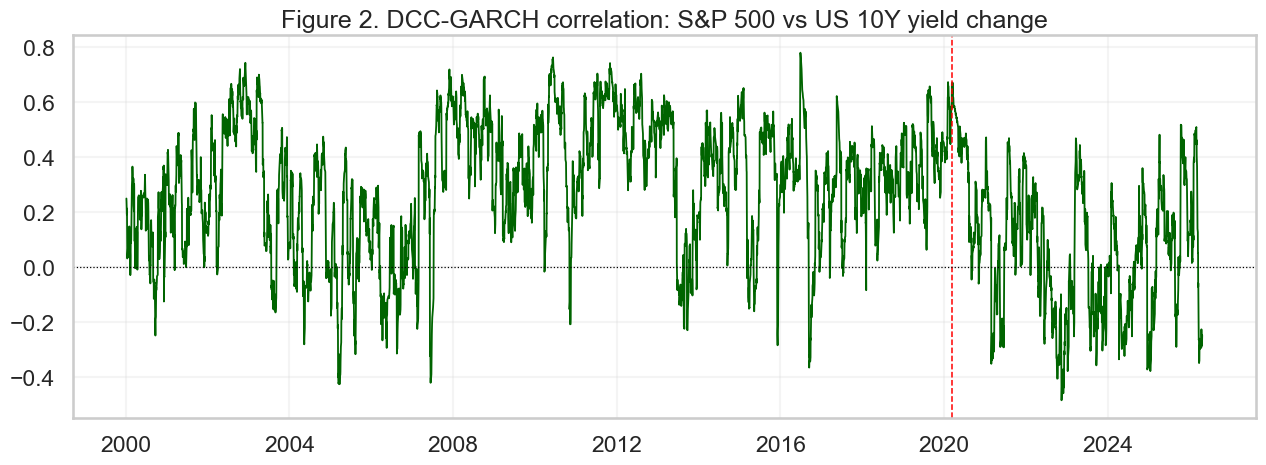

In [7]:
dcc_spx_ust_figure = plot_dcc_path(
    spx_ust_result["dcc_path"],
    "Figure 2. DCC-GARCH correlation: S&P 500 vs US 10Y yield change",
)
save_figure(dcc_spx_ust_figure, "03_spx_ust_dcc.png")
plt.show()

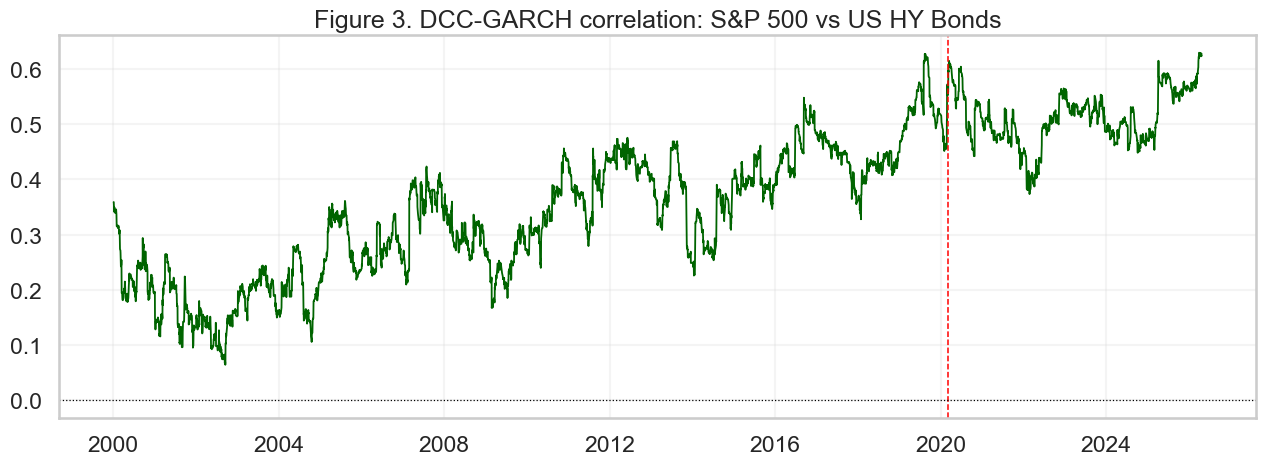

In [8]:
dcc_spx_hy_figure = plot_dcc_path(
    spx_hy_result["dcc_path"],
    "Figure 3. DCC-GARCH correlation: S&P 500 vs US HY Bonds",
)
save_figure(dcc_spx_hy_figure, "03_spx_hy_dcc.png")
plt.show()

## 6. Forbes-Rigobon adjustment

A raw correlation comparison can exaggerate contagion when one market becomes mechanically more volatile across samples. Forbes and Rigobon proposed a correction for this bias. We therefore apply their adjustment to the **post-COVID SPX / US 10Y correlation**, using the increase in S&P 500 variance as the formal scaling term. We also report the US 10Y variance ratio for transparency, because both sides of the pair become more volatile after COVID even if the correction formula uses the equity side.

In [9]:
forbes_rigobon_table = build_forbes_rigobon_table(pre_covid, post_covid)
forbes_rigobon_table

,raw_pre_corr,raw_post_corr,sp500_variance_ratio_post_pre,ust10y_variance_ratio_post_pre,forbes_rigobon_adjusted_post_corr,difference_adjusted_post_minus_pre
0,0.3872,0.1167,1.3152,1.1122,0.1020,-0.2853


## 7. Save multivariate outputs

We save the rolling-correlation summary, the DCC summary, the DCC path and the Forbes-Rigobon comparison so that the next notebooks can refer to these results directly.

In [10]:
save_multivariate_outputs(
    rolling_summary,
    dcc_parameter_summary,
    dcc_path_summary,
    forbes_rigobon_table,
    {
        "spx_ust": spx_ust_result["dcc_path"],
        "spx_hy": spx_hy_result["dcc_path"],
    },
)
save_dataframe(dcc_parameter_summary, "03_dcc_parameter_summary.csv")
save_dataframe(dcc_path_summary, "03_dcc_path_summary.csv")

## 8. Main takeaways from notebook 03

This notebook tells us whether the co-movement structure of risk changed after COVID-19. The rolling correlations provide a first descriptive answer, the two DCC models offer a volatility-adjusted dynamic view for one sovereign-rate pair and one credit-sensitive pair, and the Forbes-Rigobon adjustment helps us judge whether the observed SPX / US 10Y change is genuine or partly driven by the post-COVID jump in market variance.